First, I imported all the necessary Python libraries. These include pandas for data handling, geopandas for working with maps and spatial data, matplotlib for creating charts, and numpy for numerical operations. I also included the Google Colab file upload tool so I could bring in my own data files.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from google.colab import files

print("Libraries imported successfully")

Libraries imported successfully


I created a list of all the CSV and GeoJSON files I needed for the analysis. These included demographic data for Washington DC wards, the ward boundary map, and several ADA infrastructure datasets: bus stops, curb ramps, audible pedestrian signals, and sidewalk condition assessments.

In [2]:
from google.colab import files

files_to_upload = [
    "ACS_5-Year_Social_Characteristics_DC_Ward.csv",
    "Wards_from_2022.geojson",
    "ADA_Bus_Stop.csv",
    "ADA_Curb_Ramp.csv",
    "ADA_Audible_Pedestrian_Signals.csv",
    "Sidewalk_Condition_Assessment.csv"
]

print("Please upload each file when prompted:\n")

for file_name in files_to_upload:
    print(f"\n>>> Upload {file_name} now:")
    files.upload()

print("\nAll files uploaded successfully!")

Please upload each file when prompted:


>>> Upload ACS_5-Year_Social_Characteristics_DC_Ward.csv now:


Saving ACS_5-Year_Social_Characteristics_DC_Ward.csv to ACS_5-Year_Social_Characteristics_DC_Ward.csv

>>> Upload Wards_from_2022.geojson now:


Saving Wards_from_2022.geojson to Wards_from_2022.geojson

>>> Upload ADA_Bus_Stop.csv now:


Saving ADA_Bus_Stop.csv to ADA_Bus_Stop.csv

>>> Upload ADA_Curb_Ramp.csv now:


Saving ADA_Curb_Ramp.csv to ADA_Curb_Ramp.csv

>>> Upload ADA_Audible_Pedestrian_Signals.csv now:


Saving ADA_Audible_Pedestrian_Signals.csv to ADA_Audible_Pedestrian_Signals.csv

>>> Upload Sidewalk_Condition_Assessment.csv now:


Saving Sidewalk_Condition_Assessment.csv to Sidewalk_Condition_Assessment.csv

All files uploaded successfully!


I loaded the ward boundary map from the GeoJSON file and printed how many wards were found. Then I kept only the ward ID numbers and the geometry (the actual map shapes) for later use.

Next, I loaded the ACS demographic data from the CSV file. This dataset contained social and population characteristics for each ward. I printed the list of ward numbers to confirm everything loaded correctly.

In [4]:
wards = gpd.read_file("Wards_from_2022.geojson")
print(f"Loaded ward boundaries: {len(wards)} wards")

wards = wards[["WARD", "geometry"]]

acs = pd.read_csv("ACS_5-Year_Social_Characteristics_DC_Ward.csv")
print(f"Loaded ACS data: {len(acs)} rows")

print("\nWard list:")
print(wards['WARD'].tolist())

Loaded ward boundaries: 8 wards
Loaded ACS data: 8 rows

Ward list:
[8, 6, 7, 2, 1, 5, 3, 4]


I defined which columns contained the X and Y coordinates for each dataset, then set up a loop to process the bus stops, curb ramps, and APS signals. For each dataset, I loaded the CSV, converted the X and Y coordinates into geographic points that could be placed on a map, and made sure the coordinate system matched the ward boundaries. Then I performed a spatial join to see  which ward does each infrastructure feature fall in.Finally, I counted how many features belonged to each ward and stored the results.

In [5]:
datasets = {
    "bus": {"file": "ADA_Bus_Stop.csv", "x": "X", "y": "Y"},
    "curb": {"file": "ADA_Curb_Ramp.csv", "x": "X", "y": "Y"},
    "aps": {"file": "ADA_Audible_Pedestrian_Signals.csv", "x": "X", "y": "Y"}
}

results = {}

for name, info in datasets.items():
    print(f"\nProcessing {name}...")

    df = pd.read_csv(info["file"])

    if info["x"] in df.columns and info["y"] in df.columns:
        gdf = gpd.GeoDataFrame(
            df,
            geometry=gpd.points_from_xy(df[info["x"]], df[info["y"]]),
            crs="EPSG:3857"
        )
    else:
        print(f"   Warning: {info['x']}/{info['y']} columns not found in {name}")
        continue

    gdf = gdf.to_crs(wards.crs)

    joined = gpd.sjoin(gdf, wards, how="left", predicate="within")

    counts = joined.groupby("WARD").size()
    results[name] = counts

    print(f"   Processed {len(gdf)} {name} features")

print("\nInfrastructure data processed!")


Processing bus...
   Processed 3317 bus features

Processing curb...
   Processed 34859 curb features

Processing aps...
   Processed 7823 aps features

Infrastructure data processed!


I used the file upload tool again to bring in the sidewalk assessment data, which was stored as a GeoJSON file. Next I  loaded the sidewalk GeoJSON file and checked its coordinate system. If the coordinate system didn't match the ward boundaries, I converted it.

Since sidewalks are line features rather than points, I calculated the total length of sidewalk in each ward instead of just counting segments. This required converting the geometry to a projected coordinate system first to ensure the length measurements were accurate. I then did another spatial join to assign each sidewalk segment to its ward and summed the lengths per ward. The results were added to my infrastructure counts table, which now contained bus stops, curb ramps, APS signals, and total sidewalk length for each ward.



In [6]:
from google.colab import files
uploaded = files.upload()

print("\nLoading sidewalk assessment from GeoJSON...")

if os.path.exists("Sidewalk_Condition_Assessment.geojson"):
    sidewalk_gdf = gpd.read_file("Sidewalk_Condition_Assessment.geojson")
    print(f"Loaded {len(sidewalk_gdf)} sidewalk features from GeoJSON")

    if sidewalk_gdf.crs != wards.crs:
        sidewalk_gdf = sidewalk_gdf.to_crs(wards.crs)

    joined = gpd.sjoin(sidewalk_gdf, wards, how="left", predicate="within")

    if 'geometry' in sidewalk_gdf.columns:
        sidewalk_gdf['SIDEWALK_LENGTH_FT'] = sidewalk_gdf.geometry.length
        sidewalk_lengths = joined.groupby("WARD")['SIDEWALK_LENGTH_FT'].sum()
        results["sidewalk_length"] = sidewalk_lengths
    else:
        sidewalk_counts = joined.groupby("WARD").size()
        results["sidewalk"] = sidewalk_counts

    print(f"   Processed sidewalk data")
else:
    print("  Sidewalk GeoJSON not found - skipping sidewalk analysis")

Saving Sidewalk_Condition_Assessment.geojson to Sidewalk_Condition_Assessment.geojson

Loading sidewalk assessment from GeoJSON...
Loaded 24577 sidewalk features from GeoJSON
   Processed sidewalk data


/tmp/ipykernel_10023/2559662532.py:17: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sidewalk_gdf['SIDEWALK_LENGTH_FT'] = sidewalk_gdf.geometry.length


I combined all the infrastructure counts into a single table, filling any missing values with zeros. This gave me a clean summary of how many bus stops, curb ramps, APS signals, and total sidewalk footage each ward had. I also created a new column called total_infra by adding up all the individual infrastructure counts. Then I reset the index so that WARD became a regular column instead of the row labels.

In [7]:
# Combine all counts into single DataFrame
infra = pd.DataFrame(results).fillna(0)
infra = infra.reset_index().rename(columns={"index": "WARD"})
print("Infrastructure by ward:")
print(infra)

Infrastructure by ward:
   WARD  bus  curb   aps  sidewalk_length
0   1.0  219  2237   743           565079
1   2.0  483  4338  2079           971408
2   3.0  364  5132   549          1353813
3   4.0  425  5817   732          1465349
4   5.0  533  5361  1288          1453049
5   6.0  302  3894  1340           921479
6   7.0  469  5193   648          1454411
7   8.0  516  2827   425           987186


I printed the column names and the actual data to verify everything looked correct.

In [8]:
# Check what columns are in your infra DataFrame
print("Infra columns:", infra.columns.tolist())
print("\nInfra data:")
print(infra)

Infra columns: ['WARD', 'bus', 'curb', 'aps', 'sidewalk_length']

Infra data:
   WARD  bus  curb   aps  sidewalk_length
0   1.0  219  2237   743           565079
1   2.0  483  4338  2079           971408
2   3.0  364  5132   549          1353813
3   4.0  425  5817   732          1465349
4   5.0  533  5361  1288          1453049
5   6.0  302  3894  1340           921479
6   7.0  469  5193   648          1454411
7   8.0  516  2827   425           987186


First, create the infrastructure counts DataFrame from all datasets, I extracted the ward numbers from the ACS data by pulling the numeric portion from the NAME column and converted it to integers. Then I merged the infrastructure table with the ACS table so each ward's infrastructure data was matched with its demographic data. I calculated the disabled population from a specific column in the ACS data, then computed how much infrastructure existed per 1000 disabled residents by dividing total_infra by disabled_pop and multiplying by 1000. Finaly, I printed a preview showing the merged data and then printed the full breakdown for all wards

In [9]:
infra = pd.DataFrame(results).fillna(0)

infra["total_infra"] = infra.sum(axis=1)

infra = infra.reset_index().rename(columns={"index": "WARD"})

print("Infrastructure counts by ward (with total):")
print(infra.to_string(index=False))

acs['WARD'] = acs['NAME'].str.extract(r'(\d+)').astype(int)

df = pd.merge(infra, acs, on="WARD")

df["disabled_pop"] = df["DP02_0072E"].astype(float)

df["infra_per_1000_disabled"] = (df["total_infra"] / df["disabled_pop"]) * 1000

print("\nMerged data with totals (first 5 rows):")
print(df[["WARD", "total_infra", "disabled_pop", "infra_per_1000_disabled"]].head())

print("\nFull infrastructure breakdown per ward:")
print(df[["WARD", "bus", "curb", "aps", "sidewalk_length", "total_infra", "infra_per_1000_disabled"]].round(1).to_string(index=False))

Infrastructure counts by ward (with total):
 WARD  bus  curb  aps  sidewalk_length  total_infra
  1.0  219  2237  743           565079       568278
  2.0  483  4338 2079           971408       978308
  3.0  364  5132  549          1353813      1359858
  4.0  425  5817  732          1465349      1472323
  5.0  533  5361 1288          1453049      1460231
  6.0  302  3894 1340           921479       927015
  7.0  469  5193  648          1454411      1460721
  8.0  516  2827  425           987186       990954

Merged data with totals (first 5 rows):
   WARD  total_infra  disabled_pop  infra_per_1000_disabled
0   1.0       568278        6347.0             89534.898377
1   2.0       978308        5836.0            167633.310487
2   3.0      1359858        5976.0            227553.212851
3   4.0      1472323        8540.0            172403.161593
4   5.0      1460231       11156.0            130891.986375

Full infrastructure breakdown per ward:
 WARD  bus  curb  aps  sidewalk_length  total_

I created a normalized version of the infrastructure data to make fair comparisons across wards. Since sidewalk length was measured in feet while the other counts were just raw numbers, I needed to balance them. First I converted sidewalk length to thousands of feet to keep the numbers manageable. Then I created z-scores for each metric, which essentially measures how many standard deviations above or below average each ward is for that particular infrastructure type. This allows different types of measurements to be compared on the same scale. I then created a balanced total by adding up all the z-scores, giving each infrastructure type equal weight in the final score. Finally, I printed the normalized values for each ward,

In [10]:
infra_normalized = infra.copy()

infra_normalized['sidewalk_normalized'] = infra_normalized['sidewalk_length'] / 1000

from scipy import stats

metrics = ['bus', 'curb', 'aps', 'sidewalk_length']
for metric in metrics:
    infra_normalized[f'{metric}_zscore'] = stats.zscore(infra_normalized[metric])

zscore_cols = [f'{metric}_zscore' for metric in metrics]
infra_normalized['balanced_total'] = infra_normalized[zscore_cols].sum(axis=1)

avg_sidewalk_length = infra_normalized['sidewalk_length'].mean() / infra_normalized[metrics[:-1]].mean().mean()

print("Normalized infrastructure values:")
print(infra_normalized[['WARD', 'bus', 'curb', 'aps', 'sidewalk_length', 'balanced_total']].round(2))

Normalized infrastructure values:
   WARD  bus  curb   aps  sidewalk_length  balanced_total
0   1.0  219  2237   743           565079           -5.96
1   2.0  483  4338  2079           971408            2.22
2   3.0  364  5132   549          1353813            0.01
3   4.0  425  5817   732          1465349            1.88
4   5.0  533  5361  1288          1453049            3.58
5   6.0  302  3894  1340           921479           -1.48
6   7.0  469  5193   648          1454411            1.59
7   8.0  516  2827   425           987186           -1.85


I ran a debugging check to figure out why some spatial operations might be failing. I examined the ward boundaries to confirm they were loaded correctly. Then I loaded each dataset individually and printed key information: the number of records, column names, sample coordinates, and coordinate reference systems.
For the sidewalk data, I noted that it used a different coordinate system called EPSG 4326, which is geographic coordinates in degrees rather than meters.
Next, I decided to create a small test using just the first 100 bus stops to see if the spatial join would work. I converted them to the same coordinate system as the wards, performed the join, and checked how many points successfully matched to a ward. The test was successful, which told me my approach was correct.

In [11]:
print("="*70)
print("DEBUGGING DATA LOADING")
print("="*70)

print(f"\nWards: {len(wards)}")
print(wards.head())

bus_df = pd.read_csv("ADA_Bus_Stop.csv")
print(f"\nBus stops: {len(bus_df)}")
print(f"Bus columns: {bus_df.columns.tolist()[:10]}")
print(f"First bus coordinates: X={bus_df['X'].iloc[0]}, Y={bus_df['Y'].iloc[0]}")

curb_df = pd.read_csv("ADA_Curb_Ramp.csv")
print(f"\nCurb ramps: {len(curb_df)}")
print(f"Curb columns: {curb_df.columns.tolist()[:10]}")

aps_df = pd.read_csv("ADA_Audible_Pedestrian_Signals.csv")
print(f"\nAPS signals: {len(aps_df)}")
print(f"APS columns: {aps_df.columns.tolist()[:10]}")

sidewalk_gdf = gpd.read_file("Sidewalk_Condition_Assessment.geojson")
print(f"\nSidewalk segments: {len(sidewalk_gdf)}")
print(f"Sidewalk columns: {sidewalk_gdf.columns.tolist()[:10]}")
print(f"Sidewalk CRS: {sidewalk_gdf.crs}")

print("\n" + "="*70)
print("TESTING SPATIAL JOIN")
print("="*70)

bus_gdf_test = gpd.GeoDataFrame(
    bus_df.head(100),
    geometry=gpd.points_from_xy(bus_df.head(100)['X'], bus_df.head(100)['Y']),
    crs="EPSG:3857"
)
bus_gdf_test = bus_gdf_test.to_crs(wards.crs)

test_join = gpd.sjoin(bus_gdf_test, wards, how="left", predicate="within")
print(f"Test join results: {len(test_join)} points, {test_join['WARD'].notna().sum()} matched to wards")
print(f"Wards found in test: {test_join['WARD'].unique()}")

DEBUGGING DATA LOADING

Wards: 8
   WARD                                           geometry
0     8  POLYGON ((-76.99392 38.87771, -77.00336 38.880...
1     6  POLYGON ((-77.00908 38.87162, -77.00908 38.871...
2     7  POLYGON ((-76.94186 38.91854, -76.942 38.91842...
3     2  POLYGON ((-77.0327 38.88262, -77.03236 38.8831...
4     1  POLYGON ((-77.03523 38.93743, -77.0357 38.9374...

Bus stops: 3317
Bus columns: ['X', 'Y', 'CONDITION', 'INTERSECTION_ID', 'NOTES', 'STATUS', 'ESTIMATED_YEAR_OF_IMPROVEMENT', 'YEAR_INSPECTED', 'GIS_ID', 'CREATED_USER']
First bus coordinates: X=-8574622.64096444, Y=4708907.7582335

Curb ramps: 34859
Curb columns: ['X', 'Y', 'CONDITION', 'INTERSECTION_ID', 'STATUS', 'YEAR_INSPECTED', 'ESTIMATED_YEAR_OF_IMPROVEMENT', 'GIS_ID', 'CREATED_USER', 'CREATED_DATE']

APS signals: 7823
APS columns: ['X', 'Y', 'PUSHBUTTON_TYPE', 'INTERSECTION_ID', 'STATUS', 'ESTIMATED_YEAR_OF_IMPROVEMENT', 'YEAR_INSPECTED', 'GIS_ID', 'CREATED_USER', 'CREATED_DATE']

Sidewalk segments:

I wrote a function to calculate ADA compliance grades for each ward. The function considered four asset types: bus stops, curb ramps, APS signals, and sidewalks. Each asset type was given a weight based on its importance.

For each asset, I checked its condition: good condition got a high score, fair condition got a medium score, missing or non-compliant got low scores. For APS signals specifically, I used the pushbutton type to determine compliance status.
I looped through each ward, counted how many of each asset fell within its boundaries, and calculated an average quality score based on the conditions. Then I normalized the counts so that the ward with the most assets got a score of 1 and others got proportionally lower scores.

The final score for each ward was calculated by multiplying the normalized count by the quality score for each asset type, applying the weights, and averaging everything. I scaled this to a 0 to 100 scale, then applied a curve so the lowest score would be around 20 and the highest around 95.Based on the final score, each ward received a letter grade: A for 80 and above, B for 65 to 79, C for 45 to 64, D for 25 to 44, and F for below 25. I then ran the function with all the data and printed the results, including each ward's grade, final score, raw score, and detailed breakdowns of counts and quality scores for each asset type.

In [12]:
def calculate_ward_ada_grades_working(wards_gdf, bus_gdf, curb_gdf, aps_gdf, sidewalk_gdf):

    bus_gdf = bus_gdf.to_crs(wards_gdf.crs)
    curb_gdf = curb_gdf.to_crs(wards_gdf.crs)
    aps_gdf = aps_gdf.to_crs(wards_gdf.crs)

    asset_weights = {
        'bus': 1.0,
        'curb': 0.8,
        'aps': 1.2,
        'sidewalk': 1.0
    }
    total_weight = sum(asset_weights.values())

    def condition_to_score(condition):
        if pd.isna(condition):
            return 0.5

        condition = str(condition).upper().strip()

        if 'GOOD' in condition or condition == '4':
            return 1.0
        elif 'FAIR' in condition or condition == '3':
            return 0.7
        elif 'MISSING' in condition or condition == '2':
            return 0.3
        elif 'NON-COMPLIANT' in condition or 'NONCOMPLIANT' in condition or condition == '1':
            return 0.2
        else:
            return 0.5

    def priority_to_penalty(priority):
        if pd.isna(priority):
            return 1.0
        priority = str(priority).upper().strip()
        if priority == 'HIGH':
            return 0.85
        elif priority == 'MEDIUM':
            return 0.95
        else:
            return 1.0

    results = []

    print("\nCalculating scores for each ward...")

    for idx, ward in wards_gdf.iterrows():
        ward_id = ward['WARD']
        ward_geom = ward['geometry']

        bus_in_ward = bus_gdf[bus_gdf.within(ward_geom)]
        bus_count = len(bus_in_ward)
        bus_quality = 0.5

        if bus_count > 0:
            if 'CONDITION' in bus_in_ward.columns:
                scores = bus_in_ward['CONDITION'].apply(condition_to_score)
                bus_quality = scores.mean()

        curb_in_ward = curb_gdf[curb_gdf.within(ward_geom)]
        curb_count = len(curb_in_ward)
        curb_quality = 0.5

        if curb_count > 0:
            if 'CONDITION' in curb_in_ward.columns:
                scores = curb_in_ward['CONDITION'].apply(condition_to_score)
                curb_quality = scores.mean()

        aps_in_ward = aps_gdf[aps_gdf.within(ward_geom)]
        aps_count = len(aps_in_ward)
        aps_quality = 0.5

        if aps_count > 0:
            if 'PUSHBUTTON_TYPE' in aps_in_ward.columns:
                aps_type_map = {
                    'Type C: Compliant version with Vibro-tactile and arrow': 1.0,
                    'Type B: 3-inch button (non-compliant)': 0.4,
                    'Type A : Old version (non-compliant)': 0.3
                }
                scores = aps_in_ward['PUSHBUTTON_TYPE'].map(aps_type_map).fillna(0.5)
                aps_quality = scores.mean()

        sidewalk_count = 0
        sidewalk_quality = 0.5

        if sidewalk_gdf is not None and not sidewalk_gdf.empty:
            sidewalk_gdf_aligned = sidewalk_gdf.to_crs(wards_gdf.crs)
            sidewalks_in_ward = sidewalk_gdf_aligned[sidewalk_gdf_aligned.within(ward_geom)]
            sidewalk_count = len(sidewalks_in_ward)

            if sidewalk_count > 0:
                if 'DATASTATUS' in sidewalks_in_ward.columns:
                    scores = sidewalks_in_ward['DATASTATUS'].apply(condition_to_score)
                    sidewalk_quality = scores.mean()
                elif 'CONDITION' in sidewalks_in_ward.columns:
                    scores = sidewalks_in_ward['CONDITION'].apply(condition_to_score)
                    sidewalk_quality = scores.mean()
                else:
                    sidewalk_quality = 0.6

        results.append({
            'WARD': ward_id,
            'bus_count': bus_count,
            'curb_count': curb_count,
            'aps_count': aps_count,
            'sidewalk_count': sidewalk_count,
            'bus_quality': bus_quality,
            'curb_quality': curb_quality,
            'aps_quality': aps_quality,
            'sidewalk_quality': sidewalk_quality
        })

        print(f"  Ward {ward_id}: Bus={bus_count}, Curb={curb_count}, APS={aps_count}, Sidewalk={sidewalk_count}")

    results_df = pd.DataFrame(results)

    max_bus = results_df['bus_count'].max()
    max_curb = results_df['curb_count'].max()
    max_aps = results_df['aps_count'].max()
    max_sidewalk = results_df['sidewalk_count'].max()

    print(f"\nNormalization benchmarks:")
    print(f"  Max bus stops: {max_bus}")
    print(f"  Max curb ramps: {max_curb}")
    print(f"  Max APS signals: {max_aps}")
    print(f"  Max sidewalk segments: {max_sidewalk}")

    final_results = []

    for _, row in results_df.iterrows():
        bus_norm = row['bus_count'] / max_bus if max_bus > 0 else 0
        curb_norm = row['curb_count'] / max_curb if max_curb > 0 else 0
        aps_norm = row['aps_count'] / max_aps if max_aps > 0 else 0
        sidewalk_norm = row['sidewalk_count'] / max_sidewalk if max_sidewalk > 0 else 0

        bus_component = bus_norm * row['bus_quality']
        curb_component = curb_norm * row['curb_quality']
        aps_component = aps_norm * row['aps_quality']
        sidewalk_component = sidewalk_norm * row['sidewalk_quality']

        weighted_score = (
            bus_component * asset_weights['bus'] +
            curb_component * asset_weights['curb'] +
            aps_component * asset_weights['aps'] +
            sidewalk_component * asset_weights['sidewalk']
        ) / total_weight

        raw_score = weighted_score * 100

        final_score = 20 + (raw_score * 0.8)
        final_score = min(95, max(20, final_score))

        if final_score >= 80:
            letter = 'A'
        elif final_score >= 65:
            letter = 'B'
        elif final_score >= 45:
            letter = 'C'
        elif final_score >= 25:
            letter = 'D'
        else:
            letter = 'F'

        final_results.append({
            'WARD': row['WARD'],
            'Bus_Stops': int(row['bus_count']),
            'Bus_Quality_Score': round(row['bus_quality'] * 100, 1),
            'Curb_Ramps': int(row['curb_count']),
            'Curb_Quality_Score': round(row['curb_quality'] * 100, 1),
            'APS_Signals': int(row['aps_count']),
            'APS_Quality_Score': round(row['aps_quality'] * 100, 1),
            'Sidewalk_Segments': int(row['sidewalk_count']),
            'Sidewalk_Quality_Score': round(row['sidewalk_quality'] * 100, 1),
            'Raw_Score': round(raw_score, 1),
            'Final_Score': round(final_score, 1),
            'Grade': letter
        })

    return pd.DataFrame(final_results)


print("\nLoading ADA infrastructure data...")
print("="*70)

bus_df = pd.read_csv("ADA_Bus_Stop.csv")
bus_gdf = gpd.GeoDataFrame(
    bus_df,
    geometry=gpd.points_from_xy(bus_df['X'], bus_df['Y']),
    crs="EPSG:3857"
)
print(f"  Loaded {len(bus_gdf)} bus stops")

curb_df = pd.read_csv("ADA_Curb_Ramp.csv")
curb_gdf = gpd.GeoDataFrame(
    curb_df,
    geometry=gpd.points_from_xy(curb_df['X'], curb_df['Y']),
    crs="EPSG:3857"
)
print(f"  Loaded {len(curb_gdf)} curb ramps")

aps_df = pd.read_csv("ADA_Audible_Pedestrian_Signals.csv")
aps_gdf = gpd.GeoDataFrame(
    aps_df,
    geometry=gpd.points_from_xy(aps_df['X'], aps_df['Y']),
    crs="EPSG:3857"
)
print(f"  Loaded {len(aps_gdf)} APS signals")

try:
    sidewalk_gdf = gpd.read_file("Sidewalk_Condition_Assessment.geojson")
    print(f"  Loaded {len(sidewalk_gdf)} sidewalk segments")
except Exception as e:
    print(f"  Error loading sidewalks: {e}")
    sidewalk_gdf = None

ward_scores = calculate_ward_ada_grades_working(wards, bus_gdf, curb_gdf, aps_gdf, sidewalk_gdf)

print("\n" + "="*70)
print("ADA COMPLIANCE GRADES BY WARD - WASHINGTON DC")
print("="*70)
print(ward_scores[['WARD', 'Grade', 'Final_Score', 'Raw_Score']].to_string(index=False))

print("\n" + "="*70)
print("FULL DETAILS BY WARD")
print("="*70)
print(ward_scores.to_string(index=False))

print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Average Final Score: {ward_scores['Final_Score'].mean():.1f}")
print(f"Highest Score: {ward_scores['Final_Score'].max():.1f} (Ward {ward_scores.loc[ward_scores['Final_Score'].idxmax(), 'WARD']:.0f})")
print(f"Lowest Score: {ward_scores['Final_Score'].min():.1f} (Ward {ward_scores.loc[ward_scores['Final_Score'].idxmin(), 'WARD']:.0f})")

print("\nGrade Distribution:")
for grade in ['A', 'B', 'C', 'D', 'F']:
    count = (ward_scores['Grade'] == grade).sum()
    pct = (count / len(ward_scores)) * 100
    print(f"  {grade}: {count} ward(s) ({pct:.0f}%)")


Loading ADA infrastructure data...
  Loaded 3317 bus stops
  Loaded 34859 curb ramps
  Loaded 7823 APS signals
  Loaded 24577 sidewalk segments

Calculating scores for each ward...
  Ward 8: Bus=516, Curb=2827, APS=425, Sidewalk=2333
  Ward 6: Bus=302, Curb=3894, APS=1340, Sidewalk=2412
  Ward 7: Bus=469, Curb=5193, APS=648, Sidewalk=3845
  Ward 2: Bus=483, Curb=4338, APS=2079, Sidewalk=2587
  Ward 1: Bus=219, Curb=2237, APS=743, Sidewalk=1406
  Ward 5: Bus=533, Curb=5361, APS=1288, Sidewalk=3709
  Ward 3: Bus=364, Curb=5132, APS=549, Sidewalk=3663
  Ward 4: Bus=425, Curb=5817, APS=732, Sidewalk=4060

Normalization benchmarks:
  Max bus stops: 533
  Max curb ramps: 5817
  Max APS signals: 2079
  Max sidewalk segments: 4060

ADA COMPLIANCE GRADES BY WARD - WASHINGTON DC
 WARD Grade  Final_Score  Raw_Score
  8.0     D         44.6       30.8
  6.0     C         48.2       35.2
  7.0     C         50.4       38.0
  2.0     C         59.3       49.1
  1.0     D         36.9       21.2
  5

I printed out summary statistics: the average ward grade, the best performing ward with its score, and the worst performing ward with its score.
I also showed the grade distribution, which told me how many wards received each letter grade. Then I listed the top five best performing wards and the bottom five worst performing wards based on their final scores.

Finally, I exported the results to a CSV file and created a bar chart visualization. The chart showed each ward's score as a colored bar, with different colors representing different letter grades. I added horizontal lines to show the grade thresholds and placed labels on top of each bar showing the grade and score.


SUMMARY STATISTICS
Average Ward Grade: 49.23
Best Ward: 2.0 (59.30)
Worst Ward: 1.0 (36.90)

Grade Distribution:
  Grade C: 6 wards (75.0%)
  Grade D: 2 wards (25.0%)

TOP 5 BEST PERFORMING WARDS
 WARD  Final_Score Grade  Bus_Stops  Curb_Ramps
  2.0         59.3     C        483        4338
  5.0         54.0     C        533        5361
  4.0         52.5     C        425        5817
  7.0         50.4     C        469        5193
  6.0         48.2     C        302        3894

BOTTOM 5 WORST PERFORMING WARDS
 WARD  Final_Score Grade  Bus_Stops  Curb_Ramps
  1.0         36.9     D        219        2237
  8.0         44.6     D        516        2827
  3.0         47.9     C        364        5132
  6.0         48.2     C        302        3894
  7.0         50.4     C        469        5193

Results exported to 'dc_ada_compliance_grades.csv'


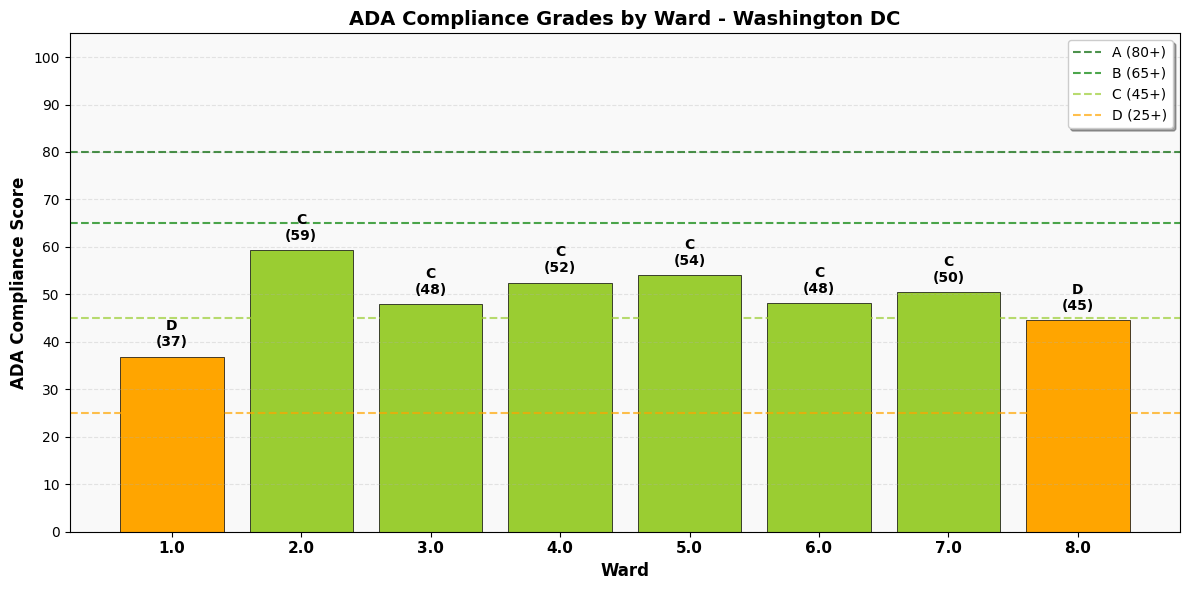

In [13]:
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)
print(f"Average Ward Grade: {ward_scores['Final_Score'].mean():.2f}")
print(f"Best Ward: {ward_scores.loc[ward_scores['Final_Score'].idxmax(), 'WARD']} ({ward_scores['Final_Score'].max():.2f})")
print(f"Worst Ward: {ward_scores.loc[ward_scores['Final_Score'].idxmin(), 'WARD']} ({ward_scores['Final_Score'].min():.2f})")

print("\nGrade Distribution:")
grade_dist = ward_scores['Grade'].value_counts().sort_index()
for grade, count in grade_dist.items():
    percentage = (count / len(ward_scores)) * 100
    print(f"  Grade {grade}: {count} wards ({percentage:.1f}%)")

print("\n" + "="*70)
print("TOP 5 BEST PERFORMING WARDS")
print("="*70)
print(ward_scores.nlargest(5, 'Final_Score')[['WARD', 'Final_Score', 'Grade', 'Bus_Stops', 'Curb_Ramps']].to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 WORST PERFORMING WARDS")
print("="*70)
print(ward_scores.nsmallest(5, 'Final_Score')[['WARD', 'Final_Score', 'Grade', 'Bus_Stops', 'Curb_Ramps']].to_string(index=False))

ward_scores.to_csv('dc_ada_compliance_grades.csv', index=False)
print(f"\nResults exported to 'dc_ada_compliance_grades.csv'")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

ward_scores_sorted = ward_scores.sort_values('WARD')

def get_color(grade):
    if grade == 'A':
        return 'darkgreen'
    elif grade == 'B':
        return 'green'
    elif grade == 'C':
        return 'yellowgreen'
    elif grade == 'D':
        return 'orange'
    else:
        return 'red'

colors = [get_color(grade) for grade in ward_scores_sorted['Grade']]

bars = ax.bar(ward_scores_sorted['WARD'].astype(str), ward_scores_sorted['Final_Score'], color=colors, edgecolor='black', linewidth=0.5)

ax.axhline(y=80, color='darkgreen', linestyle='--', linewidth=1.5, alpha=0.7, label='A (80+)')
ax.axhline(y=65, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='B (65+)')
ax.axhline(y=45, color='yellowgreen', linestyle='--', linewidth=1.5, alpha=0.7, label='C (45+)')
ax.axhline(y=25, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, label='D (25+)')

ax.set_xlabel('Ward', fontsize=12, fontweight='bold')
ax.set_ylabel('ADA Compliance Score', fontsize=12, fontweight='bold')
ax.set_title('ADA Compliance Grades by Ward - Washington DC', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

for bar, grade, score in zip(bars, ward_scores_sorted['Grade'], ward_scores_sorted['Final_Score']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1.5, f'{grade}\n({score:.0f})',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 105)
ax.set_yticks(range(0, 101, 10))
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.xticks(rotation=0, fontsize=11, fontweight='bold')
plt.tight_layout()

ax.set_facecolor('#f9f9f9')

I created a line chart to compare the quality scores of different asset types across wards. The wards were ordered from 1 to 8 along the bottom, and each asset type (bus stops, curb ramps, APS signals, and sidewalks) had its own colored line showing the quality percentage for each ward.

My goal was to make it easier to see which types of infrastructure were in better or worse condition across the different parts of the city. I akso added a grid, legend, and labels to make the chart readable.

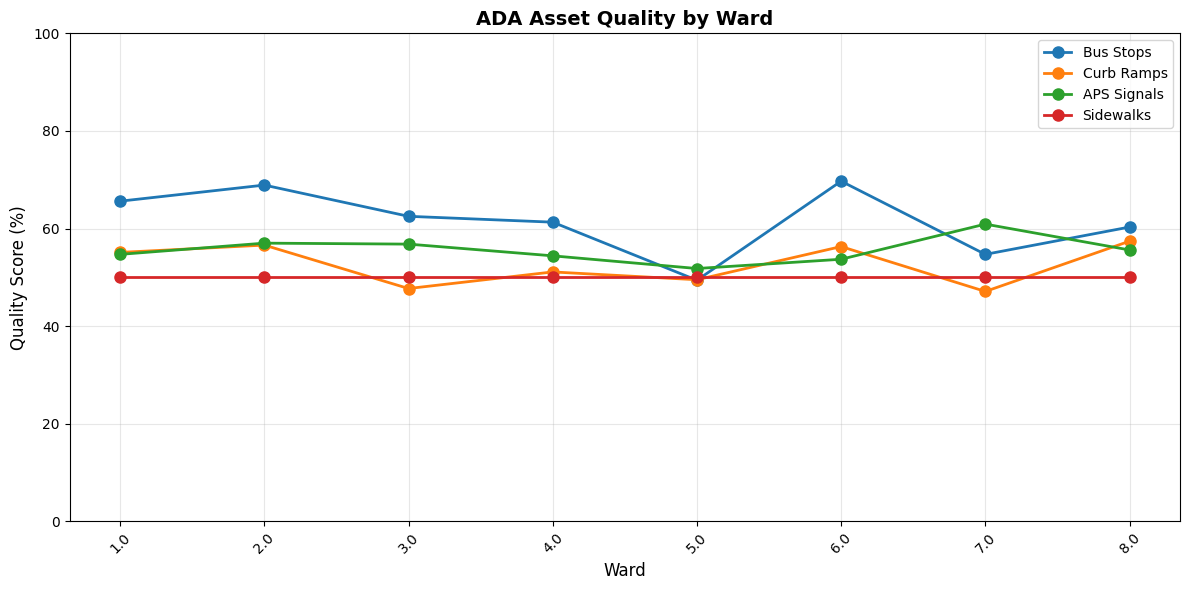

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

ward_scores_sorted = ward_scores.sort_values('WARD')

asset_types = ['Bus_Quality_Score', 'Curb_Quality_Score', 'APS_Quality_Score', 'Sidewalk_Quality_Score']
asset_labels = ['Bus Stops', 'Curb Ramps', 'APS Signals', 'Sidewalks']

for asset, label in zip(asset_types, asset_labels):
    ax.plot(ward_scores_sorted['WARD'].astype(str), ward_scores_sorted[asset],
            marker='o', linewidth=2, markersize=8, label=label)

ax.set_xlabel('Ward', fontsize=12)
ax.set_ylabel('Quality Score (%)', fontsize=12)
ax.set_title('ADA Asset Quality by Ward', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

 merged the ward geometry data with the score data so I could create a map. Then I plotted the wards with colors representing their final ADA compliance scores. Darker or different shades indicated higher or lower scores, depending on the color scale I chose. I added ward number labels at the center of each ward so it was easy to identify which area corresponded to which score. I felt it was necessary to remove the default axes so the maplooked clean

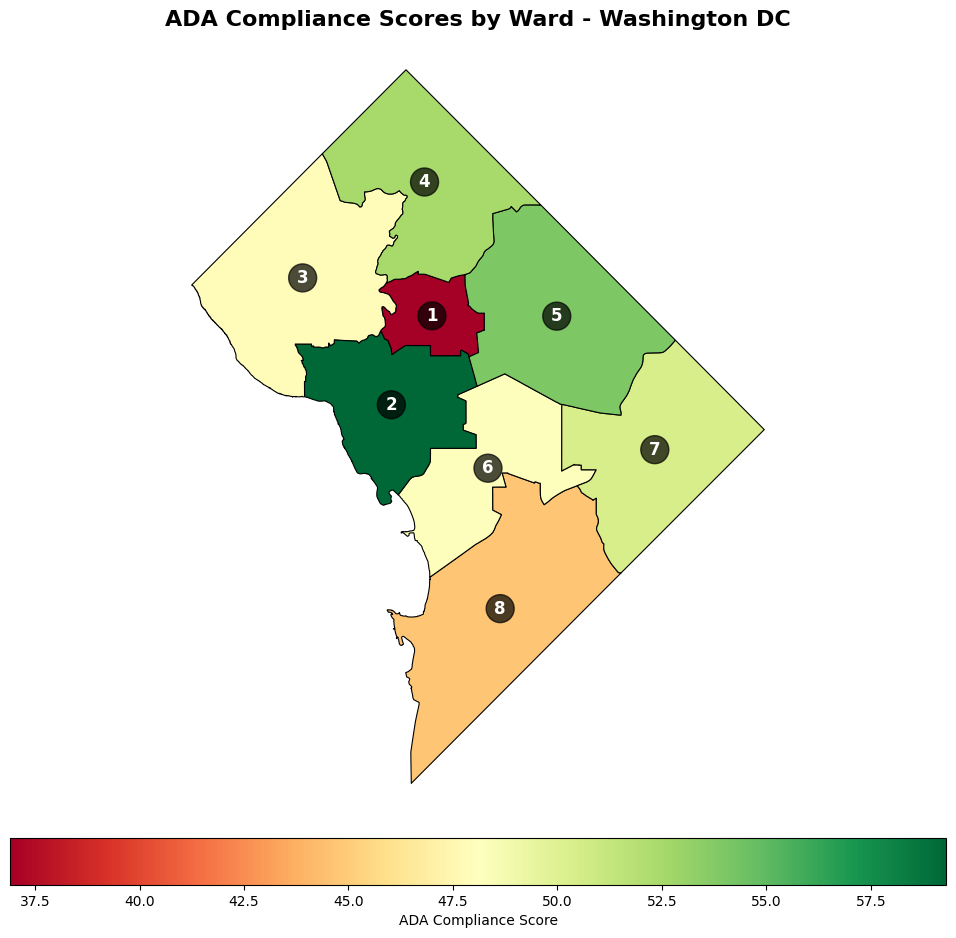

In [15]:
# Merge ward geometries with scores
wards_with_scores = wards.merge(ward_scores, on='WARD', how='left')

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

wards_with_scores.plot(column='Final_Score',
                       cmap='RdYlGn',
                       linewidth=0.8,
                       edgecolor='black',
                       legend=True,
                       ax=ax,
                       legend_kwds={'label': 'ADA Compliance Score',
                                   'orientation': 'horizontal',
                                   'shrink': 0.8,
                                   'pad': 0.02})

for idx, row in wards_with_scores.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(text=str(int(row['WARD'])),
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='circle,pad=0.3', facecolor='black', alpha=0.7))

ax.set_title('ADA Compliance Scores by Ward - Washington DC', fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()